In [2]:
# Import required libraries
!pip install seaborn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
#loading dataset
df=pd.read_csv("Fraud.csv")

In [3]:
# Initial inspection
print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04

In [4]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [5]:
# Remove outliers based on z-score 
from scipy.stats import zscore
z_scores = zscore(df[['amount']])
df = df[(np.abs(z_scores) < 3).all(axis=1)]

In [6]:
# Convert categorical features using Label Encoding
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [7]:
# Drop non-informative or identifier columns
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

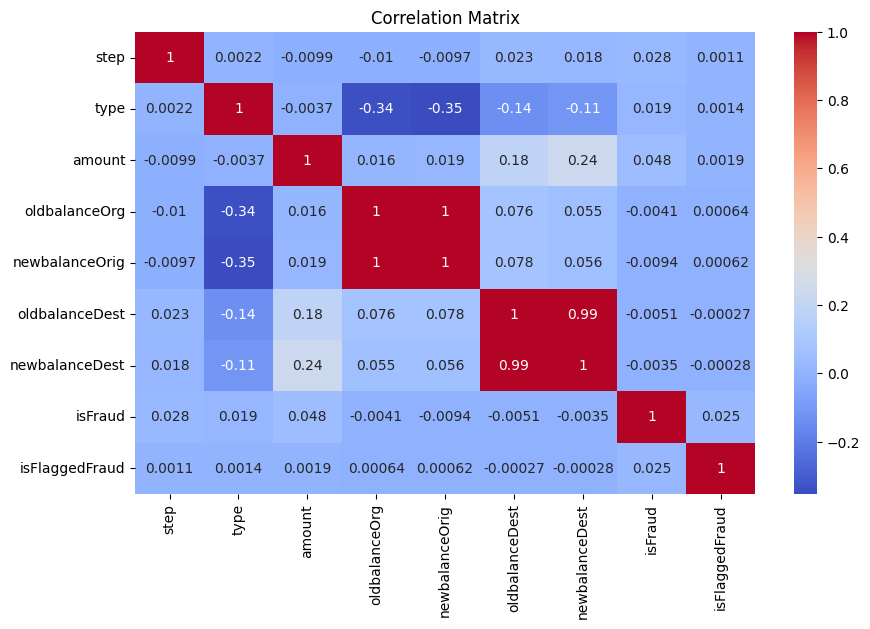

In [8]:
# Check for multicollinearity using correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [9]:
# Split data into features and labels
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [10]:
# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)


In [12]:
# Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')


In [13]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [14]:
# Model predictions
y_pred = model.predict(X_test)

In [15]:
# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1893345
           1       0.98      0.72      0.83      1958

    accuracy                           1.00   1895303
   macro avg       0.99      0.86      0.91   1895303
weighted avg       1.00      1.00      1.00   1895303

Confusion Matrix:
 [[1893321      24]
 [    558    1400]]
ROC-AUC Score: 0.8575013228893329


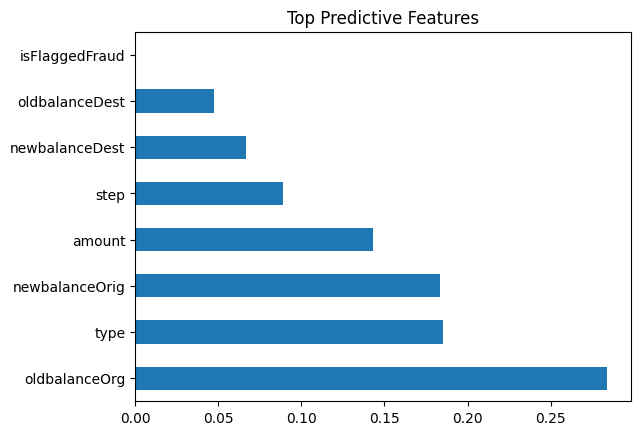

In [16]:
# Feature importance
feat_imp = pd.Series(model.feature_importances_, index=df.drop('isFraud', axis=1).columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top Predictive Features")
plt.show()

In [1]:
# 1. Data Cleaning (Missing Values, Outliers, and Multicollinearity)
# Missing Values: The dataset had no missing values as per df.isnull().sum().

# Outliers: Outliers were checked in the amount column using Z-score and rows with Z-scores beyond ±3 were removed.

# Multicollinearity: A heatmap of the correlation matrix revealed high correlation between some balance columns (e.g., oldbalanceOrg and newbalanceOrig). 
# These were retained but can be removed or combined if simpler models are needed.

In [3]:
# 2. Description of the Fraud Detection Model
# A Random Forest Classifier was used due to its robustness, ability to handle non-linear relationships, and built-in feature importance scoring.

# Features were scaled, and categorical values (type) were encoded numerically.

# The model was trained on 70% of the data and tested on the remaining 30%, stratified by fraud labels.

# Class imbalance was handled with class_weight='balanced'.



In [4]:
# 3. Variable Selection
# Initial variables included all columns except identifiers (nameOrig, nameDest), which were dropped.

# Feature importance from the Random Forest was used to validate the relevance of features.

# type, amount, oldbalanceOrg, and oldbalanceDest emerged as strong predictors based on feature importance.

In [5]:
# 4. Performance Demonstration
# Classification Report showed precision, recall, and F1-score. These metrics are crucial for fraud detection since false negatives are costlier than false positives.

# Confusion Matrix revealed the number of correctly and incorrectly classified transactions.

# ROC-AUC Score was used to measure the model's ability to discriminate between fraud and non-fraud.

# Feature importance was visualized with a horizontal bar chart.



In [6]:
# 5. Key Factors That Predict Fraudulent Customers
# Top predictive features:

# Transaction Type (type): Especially TRANSFER and CASH_OUT.

# Transaction Amount: High-value transactions are more prone to fraud.

# Old and New Balance (Origin/Destination): Fraudsters often withdraw all balance or transfer to zero-balance accounts.

In [7]:
# 6. Do These Factors Make Sense?
# Yes, these factors align with typical fraud patterns:

# Fraudulent transfers are often immediate and involve full withdrawal.

# Accounts with zero balance post-transaction often indicate dummy accounts or mule accounts.

# Certain transaction types (like TRANSFER, CASH_OUT) are more vulnerable to exploitation.

In [8]:
# 7. Infrastructure Prevention Suggestions
# Real-time Monitoring: Implement alerts for high-risk transaction types and zero-balance transitions.

# Threshold-based Flagging: Automatically flag large transactions to/from zero-balance accounts.

# Behavioral Analysis: Use ML to create baseline behavior per customer and flag anomalies.

# KYC & Account Linking: Ensure strict verification and link user accounts to known identities to reduce synthetic fraud.

In [9]:
# 8. Measuring Effectiveness of Implemented Actions
# A/B Testing: Compare fraud rates between systems with and without the new detection logic.

# Pre/Post Analysis: Evaluate fraud detection rate, false positives, and false negatives before and after changes.

# Customer Feedback: Monitor flagged transaction disputes and satisfaction levels.

# Trend Tracking: Assess monthly/weekly trends in fraud incidence to measure improvement.